# C1 — Regional sales analysis with DataCo

Ian Spikin and Juan Pablo Molina

Development of the commercial alternative selected in W1. Original candidate comparisons and exploratory tables are retained; new sections document measurement, quality, interpretation and project continuity.

https://github.com/ians513/Business-Intelligence

Authors:

- Juan Pablo Molina

- Ian Spikin

# 1. Selected problem, W1 alternatives and documentary support

The following alternatives were considered in W1. Candidate A is the selected line for C1; 

Candidate B remains as supporting evidence of the selection process.

Candidate A — Sales behavior by region:
How do the best-selling product categories vary across regions, and what factors are associated with lower sales volumes?

The proposed user is a commercial analyst. The decision is which region–category combinations should receive further commercial investigation before making assortment changes or pursuing promotional opportunities. Alternatives are to prioritize high-volume categories, investigate low-volume categories, or maintain the current approach until stronger evidence is available. This is a proposed use, not a stakeholder-validated requirement.

The analytical success criterion is a transparent, comparable prioritization supported by recorded quantities, order counts and category shares. Increasing sales is a possible future objective, not an effect demonstrated by this historical EDA. Observed transactions do not measure unmet demand or market size.

Candidate B — Logistics efficiency and delays:
How does the risk of late delivery vary across regions and product categories, and what operational factors are associated with these differences?

The goal is to identify the products with the highest number of late deliveries and the regions experiencing the most problems in order to take appropriate action.

Source used to verify and analyze the problems:

https://data.mendeley.com/datasets/8gx2fvg2k6/5

Bibliographic Sources:

### Candidate A — Sales behavior by region

**Regional and Categorical Patterns in Consumer Behavior: Revealing Trends — Trivedi (2011)**  
https://www.sciencedirect.com/science/article/abs/pii/S0022435910000795?fr=RR-2&ref=pdf_download&rr=a42693c059441e9d  
This study shows that consumer purchasing patterns can differ across both geographic locations and product categories. It supports analyzing DataCo sales at the combined region-category level because aggregated results may hide relevant local and category-specific differences.

**Cross-category Demand Effects of Price Promotions — Leeflang and Parreño-Selva (2012)**  
https://link.springer.com/article/10.1007/s11747-010-0244-z  
This study examines how price promotions affect revenues within and across product categories. It supports including product category, price and discount variables when investigating differences in sales behavior.

Together, these sources justify investigating how sales differ across regions and product categories and whether price and discounts are associated with those differences. The observed relationships will be interpreted as associations rather than causal effects.

### Candidate B — Logistics efficiency and delays


**What Is the Value of Delivering on Time? — Niemi, Hameri, Kolesnyk, and Appelqvist (2020)**

https://www.emerald.com/jamr/article-abstract/17/4/473/201694/What-is-the-value-of-delivering-on-time?redirectedFrom=fulltext  
This study quantifies the commercial consequences of delivery delays using nine years of order and delivery transactions from a sporting-goods company. It shows that longer delays are associated with greater and more persistent lost sales, supporting the analysis of late-delivery risk and operational punctuality in the DataCo supply chain.

**The Effect of Delivery Time on Repurchase Behavior in Quick Commerce — Harter, Stich, and Spann (2025)**

https://www.researchgate.net/publication/384990655_The_Effect_of_Delivery_Time_on_Repurchase_Behavior_in_Quick_Commerce  
This study finds that late deliveries negatively affect repurchase behavior and that their impact is stronger than the benefit of equally early deliveries. It supports treating the difference between scheduled and actual delivery time as a relevant logistics-performance measure with potential consequences for customer satisfaction and retention.

# 2. Seven-step problem definition

| Step | Application to the selected commercial line |
| --- | --- |
| 1. Decision | Proposed commercial analyst: prioritize region–category combinations for further investigation; alternatives are volume-led prioritization, investigation of low-volume groups, or no action pending stronger evidence. |
| 2. Success criteria | Produce defensible comparisons with explicit population, denominators and limitations. A future sales increase is not measurable as an intervention effect in this analysis. |
| 3. Business questions | Compare category shares and units per order across regions; explore item quantity by discount band within categories. |
| 4. Business process | Order registration → item quantities/prices/discounts → recorded order state → shipment. Inventory availability, customer exposure to offers, competitor prices, returns/refunds and reasons for decisions are not established by these records. |
| 5. Entities, events and states | Customers place orders containing items; order state is a recorded status, not proof of payment or realized revenue. No purchase is not an observed item row. |
| 6. Data representation | One row is an order item; Order Item Id is the candidate key; Order Id connects multiple items. One supplied source is used; no external join is needed. |
| 7. Measurement | Formulas below apply to a stated population and period; the exploratory commercial subset is compared with all-record baseline results. |

## Measurement definitions

- Recorded units: sum of Order Item Quantity over eligible items.
- Distinct orders: number of distinct Order Id values represented in the same eligible population.
- Units per order: recorded units / distinct represented orders. Orders partly affected by exclusions represent only their retained items.
- Region–category share: eligible units of category c in region r / all eligible units in region r × 100.
- Recorded sales amount per order: sum(Sales) / distinct orders; not a realized-revenue or profit measure.
- Mean quantity per item in a discount band: sum(quantity) / number of eligible items in that category and band. This is conditional on a purchase being recorded, not market demand or conversion.
- Denominators must be positive; empty groups are missing/unobserved, not automatically zero demand.

The initial outputs cover 2015-01-01 to 2018-01-31; actual coverage is recalculated. The study is historical, not evidence of current performance. January 2018 is a partial year; no full-year comparison with 2015–2017 is made. No direct MINSAL policy match is claimed for this commercial dataset.

# 3. Data sources, profiling and preparation

The source file remains unchanged. Original summaries use all recorded order items for continuity with W1. The additional commercial analysis explicitly reports exclusions and compares results with the original population.

The dataset obtained from the source mentioned in Section A is reviewed: DataCoSupplyChainDataset.csv

The CSV is the original input for this submission (from the data source provided at the start). For the purposes of packaging everything together for the project, a .parquet version of the dataset, which is equivalent to the original CSV without any changes or modifications, but compressed and smaller in size, which allows for the upload of the data to GitHub.

The DataCo Supply Chain dataset contains 180,519 records and 53 variables related to sales, products, customers, orders, and logistics processes. It includes information on product categories, regions, shipping methods, actual and scheduled delivery times, order status, and late delivery risk. This allows us to analyze sales patterns and study possible factors associated with late deliveries.

Run all cells from a fresh kernel. Paths are relative to the project; the input can be beside the notebook or in the package's data directory.

In [ ]:
from pathlib import Path
import platform
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# in case the CSV dataset was downloaded manually, it's part of the candidates
candidates = [
    Path("DataCoSupplyChainDataset.csv"),
    Path("data/DataCoSupplyChainDataset.csv"),
    Path("../data/DataCoSupplyChainDataset.csv"),
    Path("../data/dataset.parquet"),
]
data_path = None
for candidate in candidates:
    if candidate.is_file():
        data_path = candidate
        break
if data_path is None:
    raise FileNotFoundError("Place DataCoSupplyChainDataset.csv beside this notebook or in data/.")
elif data_path.suffix == '.csv':
    df = pd.read_csv(data_path, encoding="ISO-8859-1", low_memory=False).convert_dtypes()
elif data_path.suffix == '.parquet':
    df = pd.read_parquet(data_path)
df_original = df.copy(deep=True)
fuente_cargada = data_path.as_posix()
print("Dataset:", fuente_cargada)
print("Dimensions:", df.shape)



Dataset: ../data/dataset.parquet
Dimensions: (180519, 53)


In [ ]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


Datos y características del dataset:

In [ ]:
# Dimensiones del dataset
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

# Tipos de datos
display(df.dtypes)

# Valores nulos
nulos = df.isnull().sum().sort_values(ascending=False)
display(nulos[nulos > 0])

# Duplicados
print("Filas duplicadas:", df.duplicated().sum())

Filas: 180519
Columnas: 53


Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market          

Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64

Filas duplicadas: 0


### Unidad de observación y cobertura temporal

La unidad de observación del análisis es un **ítem de pedido (`Order Item`)**. Cada fila corresponde a una línea de producto asociada a un pedido e incluye información sobre producto, cantidad, venta, cliente, región y variables logísticas.

Por lo tanto, las 180.519 filas no deben interpretarse como 180.519 clientes ni como 180.519 pedidos independientes.

Además, se calcula directamente desde el dataset el período cubierto por los registros para precisar el alcance temporal del análisis.


In [ ]:
print("Número de registros:", len(df))

if "Order Item Id" in df.columns:
    print("Order Item Id únicos:", df["Order Item Id"].nunique())

if "Order Id" in df.columns:
    print("Order Id únicos:", df["Order Id"].nunique())

if "Customer Id" in df.columns:
    print("Clientes únicos:", df["Customer Id"].nunique())

if "Category Name" in df.columns:
    print("Categorías:", df["Category Name"].nunique())

if "Order Region" in df.columns:
    print("Regiones:", df["Order Region"].nunique())

date_col = "order date (DateOrders)"

if date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    print("Fecha inicial:", df[date_col].min())
    print("Fecha final:", df[date_col].max())


Número de registros: 180519
Order Item Id únicos: 180519
Order Id únicos: 65752
Clientes únicos: 20652
Categorías: 50
Regiones: 23
Fecha inicial: 2015-01-01 00:00:00
Fecha final: 2018-01-31 23:38:00


In [ ]:
print("REPRODUCIBILITY CHECK")
print("---------------------")

print("Dataset source:", fuente_cargada)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print()

# Duplicate rows
print("Duplicated rows:", df.duplicated().sum())

# Key identifier
if "Order Item Id" in df.columns:
    print("Missing Order Item Id:", df["Order Item Id"].isna().sum())
    print("Duplicated Order Item Id:", df["Order Item Id"].duplicated().sum())

# Orders
if "Order Id" in df.columns:
    print("Unique orders:", df["Order Id"].nunique())
    print("Missing Order Id:", df["Order Id"].isna().sum())

# Customers
if "Customer Id" in df.columns:
    print("Unique customers:", df["Customer Id"].nunique())

# Date coverage
if "order date (DateOrders)" in df.columns:
    fechas = pd.to_datetime(
        df["order date (DateOrders)"],
        errors="coerce"
    )

    print()
    print("DATE COVERAGE")
    print("Start date:", fechas.min())
    print("End date:", fechas.max())
    print("Invalid/missing dates:", fechas.isna().sum())

# Essential variables
columnas_clave = [
    "Order Region",
    "Category Name",
    "Order Item Quantity",
    "Order Item Discount",
    "Order Status"
]

print()
print("MISSING VALUES IN KEY VARIABLES")

for col in columnas_clave:
    if col in df.columns:
        print(f"{col}: {df[col].isna().sum()}")

# Order status distribution
if "Order Status" in df.columns:
    print()
    print("ORDER STATUS DISTRIBUTION")
    print(df["Order Status"].value_counts(dropna=False))

# Commercial subset
if "Order Status" in df.columns:
    estados_excluidos = ["CANCELED", "SUSPECTED_FRAUD"]

    df_comercial = df[
        ~df["Order Status"].isin(estados_excluidos)
    ].copy()

    print()
    print("COMMERCIAL SUBSET")
    print("Excluded statuses:", estados_excluidos)
    print("Rows retained:", df_comercial.shape[0])

    if "Order Id" in df_comercial.columns:
        print("Orders retained:", df_comercial["Order Id"].nunique())

    print(
        "Rows removed:",
        df.shape[0] - df_comercial.shape[0]
    )

print()
print("Reproducibility check completed.")

REPRODUCIBILITY CHECK
---------------------
Dataset source: ../data/dataset.parquet
Rows: 180519
Columns: 53

Duplicated rows: 0
Missing Order Item Id: 0
Duplicated Order Item Id: 0
Unique orders: 65752
Missing Order Id: 0
Unique customers: 20652

DATE COVERAGE
Start date: 2015-01-01 00:00:00
End date: 2018-01-31 23:38:00
Invalid/missing dates: 0

MISSING VALUES IN KEY VARIABLES
Order Region: 0
Category Name: 0
Order Item Quantity: 0
Order Item Discount: 0
Order Status: 0

ORDER STATUS DISTRIBUTION
Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

COMMERCIAL SUBSET
Excluded statuses: ['CANCELED', 'SUSPECTED_FRAUD']
Rows retained: 172765
Orders retained: 62897
Rows removed: 7754

Reproducibility check completed.


# 4. Data quality — Five Cs

The checks below retain the raw source and identify issues before creating an exploratory commercial subset. All-record W1 tables remain available for comparison.

| Lens | Application and decision |
| --- | --- |
| Clean | Check missing/duplicate identifiers, numeric validity, dates, statuses and monetary arithmetic. Exclude invalid essential fields and explicitly flagged cancellation/fraud states from the commercial subset; report counts. |
| Consistent | Inspect monthly regional coverage and within-order date/region consistency. No assumption of stable category availability or reporting intensity is made. |
| Conformed | No external source is joined; cross-source harmonization is not applicable. Validate category ID/name mapping within this source. |
| Current | Data describe 2015–2018; useful for a historical educational analysis, not immediate operational decisions in 2026. |
| Comprehensive | Inspect region/category/month coverage and sample sizes. Stock, exposure to promotions, unmet demand and complete lifecycle histories are not established. |

Exclusion of CANCELED and SUSPECTED_FRAUD is a declared analytical assumption, not proof that all remaining records are completed sales. Other states remain visible in the status table. The same eligible population is used for numerator and denominator.

In [ ]:
date_col = "order date (DateOrders)"
quality = pd.Series({
    "rows": len(df),
    "duplicate_rows": int(df_original.duplicated().sum()),
    "missing_item_ids": int(df["Order Item Id"].isna().sum()),
    "duplicate_item_ids": int(df["Order Item Id"].duplicated().sum()),
    "missing_order_ids": int(df["Order Id"].isna().sum()),
    "unparsed_or_missing_dates": int(df[date_col].isna().sum()),
    "missing_regions": int(df["Order Region"].isna().sum()),
    "missing_categories": int(df["Category Name"].isna().sum()),
})
display(quality.to_frame("count"))
display(df["Order Status"].value_counts(dropna=False).to_frame("items"))
numeric = ["Order Item Quantity", "Order Item Product Price", "Sales",
           "Order Item Discount", "Order Item Discount Rate", "Order Item Total"]
display(df[numeric].describe())
status = df["Order Status"].astype("string").str.strip().str.upper()
valid = (
    df["Order Item Id"].notna() & df["Order Id"].notna() &
    df[date_col].notna() & df["Order Region"].notna() &
    df["Category Name"].notna() & status.notna() &
    (df["Order Item Quantity"] > 0) &
    (df["Order Item Quantity"] % 1 == 0) &
    (df["Order Item Product Price"] >= 0) &
    (df["Sales"] >= 0) & (df["Order Item Total"] >= 0) &
    (df["Order Item Discount"] >= 0) &
    df["Order Item Discount Rate"].between(0, 1)
).fillna(False)
excluded_status = status.isin(["CANCELED", "SUSPECTED_FRAUD"])
audit_population = pd.DataFrame({
    "stage": ["All input rows", "Invalid essential fields", "Excluded states among valid rows", "Commercial subset"],
    "items": [len(df), int((~valid).sum()), int((valid & excluded_status).sum()), int((valid & ~excluded_status).sum())]
})
display(audit_population)
assert not df["Order Item Id"].duplicated().any(), "Review duplicate item IDs before continuing."
commercial = df.loc[valid & ~excluded_status].copy()
assert len(commercial) > 0, "No eligible commercial records."
order_consistency = commercial.groupby("Order Id").agg(
    regions=("Order Region", "nunique"), dates=(date_col, "nunique"))
display((order_consistency > 1).sum().to_frame("orders_with_conflicting_values"))
assert not (order_consistency > 1).any().any(), "Resolve within-order inconsistencies."
category_mapping = df.groupby("Category Id")["Category Name"].nunique()
display(category_mapping[category_mapping > 1].to_frame("names_per_category_id"))
monthly_coverage = pd.crosstab(df[date_col].dt.to_period("M"), df["Order Region"])
display((monthly_coverage > 0).sum().to_frame("months_with_records"))
display(monthly_coverage)
print("Zeros in this count table mean no recorded rows, not verified zero demand.")
display(df.groupby("Category Name").agg(first_date=(date_col, "min"),
                                       last_date=(date_col, "max"),
                                       items=("Order Item Id", "size")))
arithmetic = pd.Series({
    "Sales differs from price x quantity (tolerance 0.05)": int((
        commercial["Sales"] - commercial["Order Item Product Price"] * commercial["Order Item Quantity"]
    ).abs().gt(0.05).sum()),
    "Item Total differs from Sales - Discount (tolerance 0.05)": int((
        commercial["Order Item Total"] - (commercial["Sales"] - commercial["Order Item Discount"])
    ).abs().gt(0.05).sum())
})
display(arithmetic.to_frame("items"))
print("Commercial items:", len(commercial), "| represented orders:", commercial["Order Id"].nunique())
print("No imputation, external join or raw-file overwrite was performed.")


,count
rows,180519
duplicate_rows,0
missing_item_ids,0
duplicate_item_ids,0
missing_order_ids,0
unparsed_or_missing_dates,0
missing_regions,0
missing_categories,0


,items
Order Status,
COMPLETE,59491
PENDING_PAYMENT,39832
PROCESSING,21902
PENDING,20227
CLOSED,19616
ON_HOLD,9804
SUSPECTED_FRAUD,4062
CANCELED,3692
PAYMENT_REVIEW,1893


,Order Item Quantity,Order Item Product Price,Sales,Order Item Discount,Order Item Discount Rate,Order Item Total
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,2.127638,141.232550,203.772096,20.664741,0.101668,183.107609
std,1.453451,139.732492,132.273077,21.800901,0.070415,120.043670
min,1.000000,9.990000,9.990000,0.000000,0.000000,7.490000
25%,1.000000,50.000000,119.980003,5.400000,0.040000,104.379997
50%,1.000000,59.990002,199.919998,14.000000,0.100000,163.990005
75%,3.000000,199.990005,299.950012,29.990000,0.160000,247.399994
max,5.000000,1999.989990,1999.989990,500.000000,0.250000,1939.989990


,stage,items
0,All input rows,180519
1,Invalid essential fields,0
2,Excluded states among valid rows,7754
3,Commercial subset,172765


,orders_with_conflicting_values
regions,0
dates,0


...

Order Region,Canada,Caribbean,Central Africa,Central America,Central Asia,East Africa,East of USA,Eastern Asia,Eastern Europe,North Africa,...,South Asia,South of USA,Southeast Asia,Southern Africa,Southern Europe,US Center,West Africa,West Asia,West of USA,Western Europe
order date (DateOrders),,,,,,,,,,,,,,,,,,,,,
2015-01,0,870,0,2773,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2015-02,0,934,0,2508,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2015-03,0,926,0,2987,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2015-04,0,755,0,3196,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2015-05,0,728,0,2493,0,0,0,0,0,0,...,0,0,0,0,14,0,0,0,0,72
2015-06,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1024,0,0,0,0,3100
2015-07,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1184,0,0,0,0,2948
2015-08,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,975,0,0,0,0,3099
2015-09,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1074,0,0,0,0,3055


Zeros in this count table mean no recorded rows, not verified zero demand.


,first_date,last_date,items
Category Name,,,
Accessories,2015-01-01 01:03:00,2017-04-22 13:32:00,1780
As Seen on TV!,2017-04-29 03:32:00,2017-09-09 21:23:00,68
Baby,2017-10-07 00:41:00,2017-12-19 01:48:00,207
Baseball & Softball,2015-01-01 07:00:00,2017-09-11 00:22:00,632
Basketball,2017-09-11 12:38:00,2017-10-02 11:01:00,67
Books,2017-10-02 12:46:00,2017-12-17 06:01:00,405
Boxing & MMA,2015-01-08 23:17:00,2017-09-09 16:29:00,423
CDs,2017-10-08 05:25:00,2017-12-21 02:09:00,271
Cameras,2017-10-10 04:00:00,2017-12-21 08:07:00,592


,items
Sales differs from price x quantity (tolerance 0.05),0
Item Total differs from Sales - Discount (tolerance 0.05),0


Commercial items: 172765 | represented orders: 62897
No imputation, external join or raw-file overwrite was performed.


# 5. Exploratory commercial analysis

**Main question:** Within the recorded DataCo transactions from January 2015 to January 2018, how do category shares and units per order differ across regions, and how does recorded quantity per item vary with discounts within comparable categories?

The original W1 summaries below are retained as the all-records baseline. They are followed by quality-aware comparisons. Monetary fields describe recorded amounts; they are not treated as realized revenue without accounting and status verification.

Para responder la pregunta se utilizarán principalmente las siguientes variables del dataset:

| Field | Meaning used in this analysis |
| --- | --- |
| Order Region | Region recorded for the order; not automatically customer residence |
| Category Name | Recorded product category |
| Order Item Quantity | Quantity recorded on one order item |
| Sales | Recorded item sales amount; its relationship to price × quantity is checked below |
| Order Item Product Price | Recorded unit price |
| Order Item Discount / Discount Rate | Recorded discount amount / fraction |
| Order Item Total | Recorded item amount after discount, subject to the arithmetic check below |
| Customer Segment | Recorded customer segment |
| Order Id | Order identifier; multiple item rows may share it |
| Order Item Id | Identifier of the order item, not the product itself |
| Order Status | Recorded order state; exclusions are stated explicitly |

Source: DataCo, Mendeley Data, version 5 (2019), https://data.mendeley.com/datasets/8gx2fvg2k6/5.
The repository also provides DescriptionDataCoSupplyChain.csv. Include that dictionary in the final package and verify semantic definitions against it. Arithmetic consistency checks below do not substitute for accounting definitions or confirm currency.

In [ ]:
columnas = [
    "Order Region",
    "Category Name",
    "Order Item Quantity",
    "Sales",
    "Order Item Product Price",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Customer Segment",
    "Order Id",
    "Order Item Id"
]

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

display(df[columnas].head())

display(df[columnas].isnull().sum())

Filas: 180519
Columnas: 53


,Order Region,Category Name,Order Item Quantity,Sales,Order Item Product Price,Order Item Discount,Order Item Discount Rate,Customer Segment,Order Id,Order Item Id
0,Southeast Asia,Sporting Goods,1,327.75,327.75,13.110000,0.04,Consumer,77202,180517
1,South Asia,Sporting Goods,1,327.75,327.75,16.389999,0.05,Consumer,75939,179254
2,South Asia,Sporting Goods,1,327.75,327.75,18.030001,0.06,Consumer,75938,179253
3,Oceania,Sporting Goods,1,327.75,327.75,22.940001,0.07,Home Office,75937,179252
4,Oceania,Sporting Goods,1,327.75,327.75,29.500000,0.09,Corporate,75936,179251


Order Region                0
Category Name               0
Order Item Quantity         0
Sales                       0
Order Item Product Price    0
Order Item Discount         0
Order Item Discount Rate    0
Customer Segment            0
Order Id                    0
Order Item Id               0
dtype: int64

In [ ]:
ventas_region = (
    df.groupby("Order Region")["Order Item Quantity"]
      .agg(["sum", "count"])
      .sort_values("sum", ascending=False)
)

ventas_region.columns = [
    "Unidades vendidas",
    "Cantidad de registros"
]

display(ventas_region)

,Unidades vendidas,Cantidad de registros
Order Region,,
Central America,62091,28341
Western Europe,56504,27109
South America,32647,14935
Oceania,20430,10148
Northern Europe,20402,9792
Southern Europe,19526,9431
Southeast Asia,18835,9539
Caribbean,18204,8318
West of USA,17547,7993


In [ ]:
ventas_categoria = (
    df.groupby("Category Name")["Order Item Quantity"]
      .agg(["sum", "count"])
      .sort_values("sum", ascending=False)
)

ventas_categoria.columns = [
    "Unidades vendidas",
    "Cantidad de registros"
]

display(ventas_categoria)

,Unidades vendidas,Cantidad de registros
Category Name,,
Cleats,73734,24551
Women's Apparel,62956,21035
Indoor/Outdoor Games,57803,19298
Cardio Equipment,37587,12487
Shop By Sport,32726,10984
Men's Footwear,22246,22246
Fishing,17325,17325
Water Sports,15540,15540
Camping & Hiking,13729,13729


In [ ]:
ventas_region_categoria = (
    df.groupby(["Order Region", "Category Name"])["Order Item Quantity"]
      .sum()
      .reset_index()
      .sort_values(
          ["Order Region", "Order Item Quantity"],
          ascending=[True, False]
      )
)

top_categorias_region = (
    ventas_region_categoria
    .groupby("Order Region")
    .head(5)
)

display(top_categorias_region)

,Order Region,Category Name,Order Item Quantity
5,Canada,Cleats,428
23,Canada,Women's Apparel,350
16,Canada,Indoor/Outdoor Games,334
4,Canada,Cardio Equipment,248
19,Canada,Shop By Sport,189
...,...,...,...
662,Western Europe,Cleats,10977
689,Western Europe,Women's Apparel,9510
678,Western Europe,Indoor/Outdoor Games,8153
660,Western Europe,Cardio Equipment,5714


In [ ]:
ventas_precio = (
    df.groupby("Category Name")
      .agg(
          unidades_vendidas=("Order Item Quantity", "sum"),
          precio_promedio=("Order Item Product Price", "mean")
      )
      .sort_values("unidades_vendidas", ascending=False)
)

ventas_precio

,unidades_vendidas,precio_promedio
Category Name,,
Cleats,73734,60.341922
Women's Apparel,62956,50.000000
Indoor/Outdoor Games,57803,49.980000
Cardio Equipment,37587,98.207599
Shop By Sport,32726,40.631211
Men's Footwear,22246,129.990005
Fishing,17325,399.980011
Water Sports,15540,200.376106
Camping & Hiking,13729,299.980011


In [ ]:
ventas_descuento = (
    df.groupby("Category Name")
      .agg(
          unidades_vendidas=("Order Item Quantity", "sum"),
          descuento_promedio=("Order Item Discount Rate", "mean")
      )
      .sort_values("unidades_vendidas", ascending=False)
)

display(ventas_descuento)

,unidades_vendidas,descuento_promedio
Category Name,,
Cleats,73734,0.101594
Women's Apparel,62956,0.101669
Indoor/Outdoor Games,57803,0.101493
Cardio Equipment,37587,0.101651
Shop By Sport,32726,0.101362
Men's Footwear,22246,0.101683
Fishing,17325,0.101681
Water Sports,15540,0.101683
Camping & Hiking,13729,0.101681


### Comparación normalizada por pedido

Las ventas totales pueden ser mayores en una región simplemente porque existen más pedidos. Para evitar una interpretación basada solo en volumen absoluto, se calculan también **unidades por pedido** y **ventas por pedido**.


In [ ]:
ventas_region_normalizadas = (
    df.groupby("Order Region")
      .agg(
          unidades_totales=("Order Item Quantity", "sum"),
          pedidos=("Order Id", "nunique"),
          ventas_totales=("Sales", "sum")
      )
)

ventas_region_normalizadas["unidades_por_pedido"] = (
    ventas_region_normalizadas["unidades_totales"] /
    ventas_region_normalizadas["pedidos"]
)

ventas_region_normalizadas["ventas_por_pedido"] = (
    ventas_region_normalizadas["ventas_totales"] /
    ventas_region_normalizadas["pedidos"]
)

display(
    ventas_region_normalizadas.sort_values(
        "ventas_por_pedido",
        ascending=False
    )
)


,unidades_totales,pedidos,ventas_totales,unidades_por_pedido,ventas_por_pedido
Order Region,,,,,
East Africa,4048,613,3.762349e+05,6.603589,613.760029
Canada,2183,309,1.868610e+05,7.064725,604.728296
Central America,62091,9396,5.665712e+06,6.608238,602.991922
Eastern Europe,8806,1292,7.742666e+05,6.815789,599.277527
Central Asia,1214,184,1.098399e+05,6.597826,596.956153
North Africa,7155,1064,6.347522e+05,6.724624,596.571638
West Africa,8193,1223,7.279512e+05,6.699101,595.217657
US Center,12974,1935,1.151356e+06,6.704910,595.015904
South America,32647,4979,2.960881e+06,6.556939,594.673912


Los resultados iniciales permiten identificar diferencias en el volumen de ventas entre regiones y categorías de productos. Sin embargo, los valores absolutos no deben interpretarse automáticamente como diferencias en preferencias, ya que una región con una mayor cantidad de pedidos también tenderá a acumular más unidades vendidas.

Por esta razón, el análisis se complementa con métricas normalizadas por pedido. Además, variables como el precio y el descuento se consideran **factores potencialmente asociados** al comportamiento de ventas. En esta etapa, las relaciones observadas se interpretan como asociaciones y no como efectos causales.


## Additional commercial comparisons

These outputs use the eligible subset defined in Section 4. Category shares measure composition of recorded units, not market share. Coverage differences may reflect assortment changes, availability or reporting, not only preferences. Missing region–category combinations are left unobserved in the heatmap.

,units,orders,items,recorded_sales,units_per_order
Order Region,,,,,
Central America,59540,9001,27174,5.432827e+06,6.614821
Western Europe,53943,9563,25867,5.628939e+06,5.640803
South America,30978,4738,14184,2.812832e+06,6.538202
Oceania,19592,4175,9733,1.934644e+06,4.692695
Northern Europe,19561,3564,9408,2.072365e+06,5.488496
Southern Europe,18676,3390,9030,1.956697e+06,5.509145
Southeast Asia,18062,4173,9136,1.850921e+06,4.328301
Caribbean,17400,2675,7951,1.578670e+06,6.504673
West of USA,16635,2536,7595,1.490408e+06,6.559543


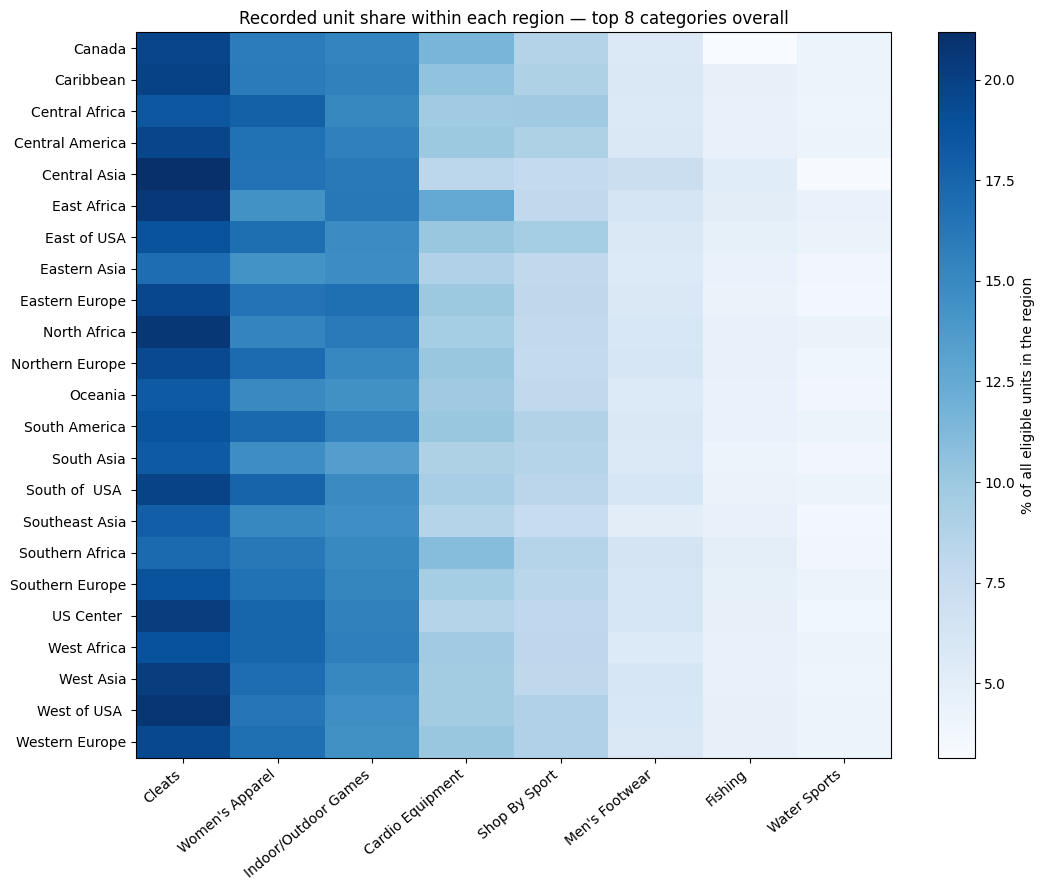

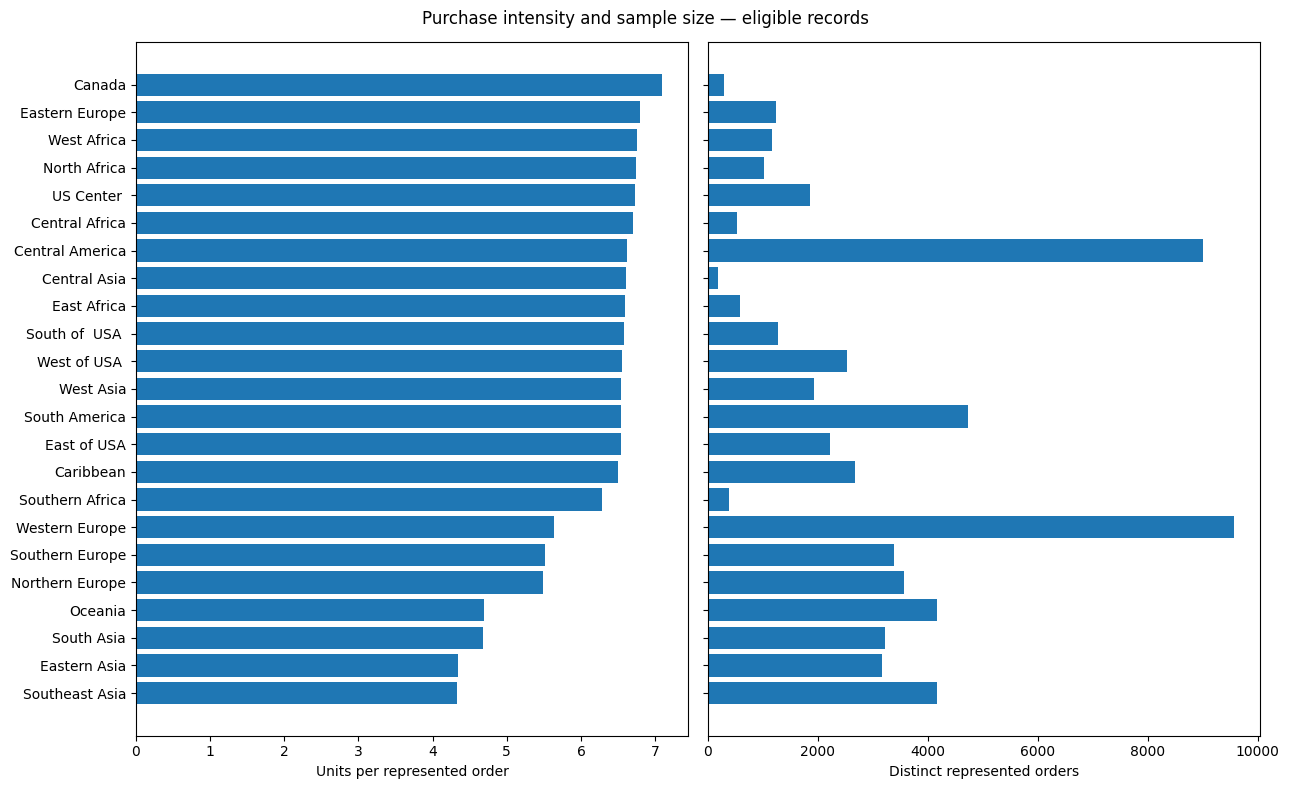

share_change_pp_after_status_exclusions
Order Region    Category Name                                                
Southern Africa Women's Apparel                                     -0.542277
Central Asia    Indoor/Outdoor Games                                -0.506417
                Cleats                                               0.418645
Canada          Accessories                                         -0.265214
Central Asia    Cardio Equipment                                    -0.250716
Southern Africa Shop By Sport                                        0.247518
East Africa     Women's Apparel                                     -0.238504
Southern Africa Golf Balls                                          -0.233097
Eastern Europe  Cleats                                              -0.231961
West of USA     Shop By Sport                                        0.229068

**Observed:** Central America has the highest retained unit volume (59,540), while Canada has the highest units per represented order (7.09). Volume and basket intensity answer different questions. Neither establishes unmet demand, profitability or a causal promotion opportunity.

In [ ]:
region_commercial = commercial.groupby("Order Region").agg(
    units=("Order Item Quantity", "sum"),
    orders=("Order Id", "nunique"),
    items=("Order Item Id", "size"),
    recorded_sales=("Sales", "sum"))
region_commercial["units_per_order"] = region_commercial["units"] / region_commercial["orders"]
display(region_commercial.sort_values("units", ascending=False))
mix = commercial.groupby(["Order Region", "Category Name"])["Order Item Quantity"].sum().unstack()
shares = mix.div(mix.sum(axis=1), axis=0) * 100
top_categories = commercial.groupby("Category Name")["Order Item Quantity"].sum().nlargest(8).index
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(shares[top_categories].to_numpy(dtype=float), aspect="auto", cmap="Blues")
ax.set_xticks(range(len(top_categories)), top_categories, rotation=40, ha="right")
ax.set_yticks(range(len(shares.index)), shares.index)
ax.set_title("Recorded unit share within each region — top 8 categories overall")
fig.colorbar(im, ax=ax, label="% of all eligible units in the region")
plt.tight_layout()
plt.show()
plt.close(fig)

ordered = region_commercial.sort_values("units_per_order")
fig, axes = plt.subplots(1, 2, figsize=(13, 8), sharey=True)
axes[0].barh(ordered.index, ordered["units_per_order"].astype(float))
axes[0].set_xlabel("Units per represented order")
axes[1].barh(ordered.index, ordered["orders"].astype(float))
axes[1].set_xlabel("Distinct represented orders")
fig.suptitle("Purchase intensity and sample size — eligible records")
plt.tight_layout()
plt.show()
plt.close(fig)

baseline_mix = df.loc[valid].groupby(["Order Region", "Category Name"])["Order Item Quantity"].sum().unstack()
baseline_shares = baseline_mix.div(baseline_mix.sum(axis=1), axis=0) * 100
sensitivity = (shares - baseline_shares).stack().sort_values(key=lambda s: s.abs(), ascending=False)
display(sensitivity.head(10).to_frame("share_change_pp_after_status_exclusions"))
top_volume = region_commercial["units"].idxmax()
top_intensity = region_commercial["units_per_order"].idxmax()
display(Markdown(
    f"**Observed:** {top_volume} has the highest retained unit volume "
    f"({region_commercial.loc[top_volume, 'units']:,.0f}), while {top_intensity} has the highest "
    f"units per represented order ({region_commercial.loc[top_intensity, 'units_per_order']:.2f}). "
    "Volume and basket intensity answer different questions. Neither establishes unmet demand, "
    "profitability or a causal promotion opportunity."
))


### Discount comparison within categories

Compare quantity per recorded item within the same category and discount band, displaying group size and price. These are descriptive associations; customer selection, product mix, region, time and price are not held constant. No elasticity, significance or causal effect is estimated. Groups below 30 items are retained in the table but suppressed in the chart as a descriptive display rule, not a statistical validity threshold.

items  mean_quantity  mean_price
Category Name        discount_band                                  
Cleats               0%              1314          3.008      60.355
                     (0,5]%          5253          3.005      60.356
                     (5,10]%         5240          3.006      60.402
                     (10,15]%        3896          3.002      60.236
                     >15%            7811          2.999      60.389
Women's Apparel      0%              1120          3.001      50.000
                     (0,5]%          4482          2.997      50.000
                     (5,10]%         4480          2.994      50.000
                     (10,15]%        3329          2.992      50.000
                     >15%            6705          2.992      50.000
Indoor/Outdoor Games 0%              1012          3.030      49.980
                     (0,5]%          4126          2.991      49.980
                     (5,10]%         4120          2.990      49.980
                     (10,15]%        3062          2.999      49.980
                     >15%            6150          2.996      49.980
Cardio Equipment     0%               677          2.996      97.612
                     (0,5]%          2661          3.009      98.359
                     (5,10]%         2643          3.004      98.083
                     (10,15]%        1993          3.010      98.269
                     >15%            3974          3.010      98.299
Shop By Sport        0%               593          3.012      40.833
                     (0,5]%          2337          2.991      40.568
                     (5,10]%         2343          2.980      40.584
                     (10,15]%        1734          2.967      40.469
                     >15%            3508          2.972      40.689

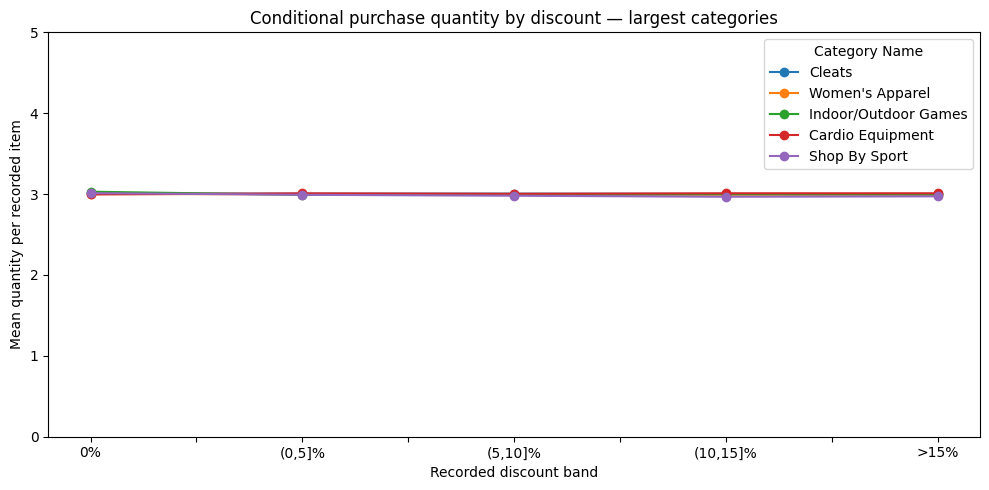

,max_minus_min_mean_quantity
Category Name,
Cleats,0.008378
Women's Apparel,0.008797
Indoor/Outdoor Games,0.039353
Cardio Equipment,0.014748
Shop By Sport,0.044676


**Interpretation:** the table and chart compare purchase quantities conditional on observed transactions. Small differences or flat profiles are valid findings and do not support assuming that larger discounts increase demand. Any visible differences still require adjustment for product, region and period. Prices and discounts are not randomized, and transactions without purchases are absent.

In [ ]:
discount_data = commercial.copy()
discount_data["discount_band"] = pd.cut(
    discount_data["Order Item Discount Rate"].astype(float),
    bins=[-0.000001, 0, 0.05, 0.10, 0.15, 1],
    labels=["0%", "(0,5]%", "(5,10]%", "(10,15]%", ">15%"])
discount_summary = discount_data.groupby(
    ["Category Name", "discount_band"], observed=True
).agg(items=("Order Item Id", "size"),
      mean_quantity=("Order Item Quantity", "mean"),
      mean_price=("Order Item Product Price", "mean"))
display(discount_summary.loc[top_categories[:5]].round(3))
discount_plot = discount_summary.loc[top_categories[:5]].copy()
discount_plot.loc[discount_plot["items"] < 30, "mean_quantity"] = np.nan
ax = discount_plot["mean_quantity"].unstack().T.plot(marker="o", figsize=(10, 5))
ax.set_ylabel("Mean quantity per recorded item")
ax.set_ylim(0, 5)
ax.set_xlabel("Recorded discount band")
ax.set_title("Conditional purchase quantity by discount — largest categories")
plt.tight_layout()
plt.show()
plt.close()
spreads = discount_plot["mean_quantity"].unstack().apply(lambda row: row.max() - row.min(), axis=1)
display(spreads.to_frame("max_minus_min_mean_quantity"))
display(Markdown(
    "**Interpretation:** the table and chart compare purchase quantities conditional on observed transactions. "
    "Small differences or flat profiles are valid findings and do not support assuming that larger discounts "
    "increase demand. Any visible differences still require adjustment for product, region and period. "
    "Prices and discounts are not randomized, and transactions without purchases are absent."
))


## W1 supporting alternative — Candidate B

The following historical comparison is retained. Percentages are item-weighted shares of records labeled Late_delivery_risk = 1, not an independently estimated prospective probability or necessarily a percentage of distinct deliveries.

“¿Cómo varía el riesgo de entrega tardía entre regiones y categorías de productos, y qué factores operacionales están asociados a estas diferencias?”

Para responder la pregunta se utilizarán principalmente las siguientes variables del dataset:

**Late_delivery_risk**: indica si una entrega presenta riesgo de atraso.  
**Order** **Region**: permite comparar el comportamiento de las entregas entre distintas regiones.  
**Category** **Name**: identifica la categoría del producto asociado al pedido.  
**Shipping** **Mode**: representa la modalidad de envío utilizada.  
**Days** **for** **shipping** (real): cantidad de días reales que tomó el envío.  
**Days** **for** **shipment** (scheduled): cantidad de días programados para realizar el envío.  

In [ ]:
columnas = [
    "Late_delivery_risk",
    "Order Region",
    "Category Name",
    "Shipping Mode",
    "Days for shipping (real)",
    "Days for shipment (scheduled)"
]

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

display(df[columnas].head())
display(df[columnas].isnull().sum())

Filas: 180519
Columnas: 53


,Late_delivery_risk,Order Region,Category Name,Shipping Mode,Days for shipping (real),Days for shipment (scheduled)
0,0,Southeast Asia,Sporting Goods,Standard Class,3,4
1,1,South Asia,Sporting Goods,Standard Class,5,4
2,0,South Asia,Sporting Goods,Standard Class,4,4
3,0,Oceania,Sporting Goods,Standard Class,3,4
4,0,Oceania,Sporting Goods,Standard Class,2,4


Late_delivery_risk               0
Order Region                     0
Category Name                    0
Shipping Mode                    0
Days for shipping (real)         0
Days for shipment (scheduled)    0
dtype: int64

In [ ]:
riesgo_region = (
    df.groupby("Order Region")["Late_delivery_risk"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

riesgo_region["mean"] *= 100

riesgo_region.columns = [
    "Riesgo de atraso (%)",
    "Cantidad de registros"
]

display(riesgo_region)

,Riesgo de atraso (%),Cantidad de registros
Order Region,,
Central Africa,57.960644,1677
South Asia,56.266977,7731
East Africa,55.939525,1852
Western Europe,55.848611,27109
South of USA,55.772559,4045
Eastern Europe,55.663265,3920
East of USA,55.661605,6915
Southeast Asia,55.529930,9539
Central Asia,55.334539,553


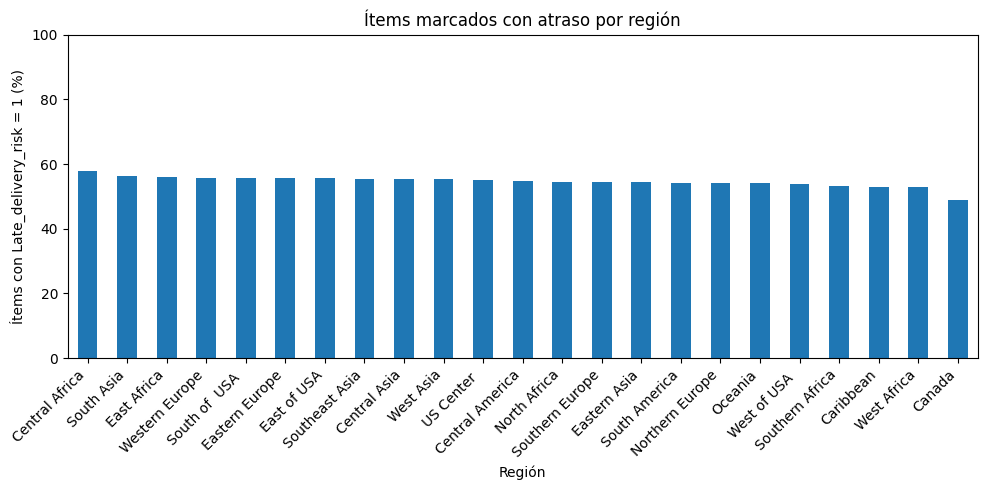

In [ ]:
import matplotlib.pyplot as plt

# Gráfico del riesgo de entrega tardía por región
ax = riesgo_region["Riesgo de atraso (%)"].plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_title("Ítems marcados con atraso por región")
ax.set_ylim(0, 100)
ax.set_ylabel("Ítems con Late_delivery_risk = 1 (%)")
ax.set_xlabel("Región")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.close()

In [ ]:
riesgo_envio = (
    df.groupby("Shipping Mode")["Late_delivery_risk"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

riesgo_envio["mean"] *= 100

display(riesgo_envio)

,mean,count
Shipping Mode,,
First Class,95.322499,27814
Second Class,76.632781,35216
Same Day,45.743042,9737
Standard Class,38.071683,107752


Los resultados permiten observar si existen diferencias en el riesgo de entrega tardía entre regiones y modalidades de envío. Estas variaciones pueden estar asociadas a factores operacionales, aunque en esta etapa no se puede afirmar una relación causal.

# 6. Selection, conclusions and limitations

The original comparison records the rationale for continuing Candidate A. The commercial conclusions below distinguish observed records from interpretations and untested explanations.

Ambos candidatos dados presentan una clara oportunidad de analisis, ambos tienen enfoques distintos. 
El candidato A se orienta al comportamiento de las ventas, mientras que el candidato B se enfoca en el riesgo de atraso de los pedidos


| Categorías      | Candidato A | Candidato B |
| -------- | ----------- | ----------- |
| Objetivo |  Analizar diferencias de ventas entre regiones y categorías.           | Analizar el riesgo de atraso según región, categoría y modalidad de envío.            |
|  Datos disponibles:        |Región, categoría, ventas, precio y descuentos.             | Riesgo de atraso, región, categoría, modalidad y tiempos de entrega.            |
|Oportunidad:          |  Identificar patrones comerciales y factores asociados a las ventas.           |     Identificar factores asociados a una mayor probabilidad de atraso.        |
|Limitación:          | Las diferencias de ventas pueden depender de factores externos no disponibles.            |Se debe verificar cómo se construye Late_delivery_risk y qué variables están disponibles antes de la entrega.             |
|ML futuro:          | Predicción de ventas.            |    Clasificación del riesgo de atraso.         |
|Dashboard:          |  Ventas por región, categoría y producto.           | Riesgo de atraso por región, categoría y modalidad de envío.            |


Elegimos el Candidato A, ya que permite analizar el comportamiento histórico de las ventas entre regiones y categorías utilizando diferentes variables disponibles en el dataset. Esto permitiría identificar productos con mayor y menor demanda y analizar factores asociados como precio y descuentos. Además, presenta potencial para desarrollar posteriormente un modelo predictivo de ventas y un dashboard comercial.
Nuestra elección podría cambiar si se determina que las variables disponibles no permiten explicar suficientemente las diferencias de ventas entre regiones.

For candidate B, there's some interesting initial findings, with two main outliers: Canada and Central Africa, as Canada has a lower risk of a late delivery compared to other regions, whereas Central Africa has an overall risk higher than the mean, with the difference between these two regions being around 10pp.

Candidate B remains a feasible descriptive or future predictive line. Its limitations concern missing operational causes and whether predictors are available before delivery; these limitations do not establish that machine learning is unhelpful. The team retains Candidate A because region, category, quantities, prices and discounts support its proposed commercial comparisons. Neither alternative establishes causal effects from these data alone. The four shipping modes should not be confused with the 50 product categories.

### Questions retained from W1 for subsequent feedback

Does the commercial line have sufficient analytical depth? Which regional and category comparisons are most useful for the proposed decision?

¿Sería más conveniente mantener el análisis de ventas considerando región y categoría, o enfocarlo principalmente en una de estas dimensiones?

In response to the feedback received by the professor, C1 added specific academic support for regional/category sales analysis and promotions (added 2 sources for candidate A), explicitly defined the observation unit as an Order Item, stated the covered period: from 2015-01 until 2018-01, with most regions having recorded periods that fall in between this time range. The notebook was executed and saved with all the outputs, and the reproducibility documentation was improved.

## Conclusions, decision implications and boundaries

**Executed findings:** the CSV contains 180,519 unique item records. Essential-field validation found no invalid rows; excluding 3,692 CANCELED and 4,062 SUSPECTED_FRAUD items leaves 172,765 items representing 62,897 orders. No monetary arithmetic discrepancies above 0.05 were found in the retained subset.

Central America records 59,540 retained units; Canada records 2,063 but has 7.09 units per represented order. The largest observed absolute category-share change after the status exclusion is about 0.54 percentage points. This sensitivity result is specific to the stated exclusion and does not establish realized revenue.

In the five largest categories, the difference between the highest and lowest mean item quantity across discount bands is only 0.008–0.045 units, around a mean of 3. This descriptive result does not justify recommending deeper discounts.

**Material coverage finding:** Canada's records occur from August 2016 through January 2017, whereas other regions have different observation windows. Product categories also have unequal date coverage. Whole-period regional rankings therefore combine time, assortment and geography; units per order do not remove those confounders. Treat these rankings as dataset descriptions, not comparable regional performance. A subsequent comparison must use overlapping periods and available categories, and report its restricted sample.

The regional summaries distinguish total recorded volume from units per represented order. Category shares add a composition view; the sensitivity table measures how excluding cancellation/fraud states changes those shares. The discount comparison investigates the factor mentioned in the original question without assuming a positive relationship.

**Proposed decision:** use volume, shares, units per order and sample sizes jointly to shortlist region–category combinations for investigation. Do not prescribe larger discounts from these comparisons alone. Review reporting coverage and assortment first; then seek inventory, campaign exposure/cost, margins and customer opportunity data before making investment decisions.

**Alternative explanations:** regional activity levels, product availability, category mix, order states and unequal temporal coverage can explain differences. Lower recorded sales are not proof of market failure or low underlying demand. Currency/accounting meaning must be checked against documentation before interpreting money values as revenue. Findings are historical.

# 7. Future ML and dashboard feasibility

**Possible future ML task:** forecast next month's recorded units for a region–category pair. The unit would be region–category–month; the outcome is next-month units. Inputs could include prior-month quantities, prior order counts, lagged category shares and calendar variables. Realized prices, discounts, order states and sales from the forecast month are unavailable at prediction time and must not be used as known predictors. Future promotion plans could be inputs only if actually available in advance.

The roughly three-year window, incomplete final year and uneven category coverage may make many series unsuitable. Confirm reporting completeness and distinguish unobserved months from true zeros before assessing feasibility; narrow to sufficiently covered categories if necessary. The observed gaps materially weaken regional monthly forecasting feasibility. If contiguous comparable series are unavailable, a fallback is exploratory clustering of region–category profiles within overlapping periods, using shares, units per order and recorded price/discount summaries. Clustering requires no invented outcome labels; its value would be to identify similar observed profiles for investigation. Coverage and group size must be checked first. Inventory, promotion plans and assortment histories would improve interpretation. No model is trained and no accuracy is promised in C1.

**Proposed dashboard:** a commercial analyst/category manager could compare regions and categories to select investigation priorities. Core indicators are recorded units, represented orders, units per order and within-region category shares. Filters: month, region, category, customer segment and inclusion/exclusion of flagged statuses. Show sample sizes and coverage warnings alongside rankings. The EDA motivates showing composition and intensity separately from volume, plus a discount comparison explicitly labeled descriptive.

# 8. Process record and reproducibility

## Execution and delivery

Execute the notebook from a fresh kernel from top to bottom and save its outputs. The loading cell reports the actual input, hash and software versions. Review the quality checks and narrative outputs before exporting the report.

The final C1 package also needs a self-contained report PDF, slides PDF, README, relevant input/prepared tables, and the group ID. This notebook alone does not replace those deliverables. Do not include tmp/, installed libraries or caches in the archive.

In [ ]:
print("- Libraries and versions (reproducibility) -")
print(f"OS Platform:     {platform.platform()}")
print(f"Python Version:  {platform.python_version()}")
print(f"Pandas Version:  {pd.__version__}")
print(f"NumPy Version:   {np.__version__}")
print(f"Matplotlib Ver:  {matplotlib.__version__}")

- Libraries and versions (reproducibility) -
OS Platform:     Linux-7.2.7-200.fc44.x86_64-x86_64-with-glibc2.43
Python Version:  3.13.2
Pandas Version:  2.3.2
NumPy Version:   2.3.2
Matplotlib Ver:  3.10.5


Project repository: https://github.com/ians513/Business-Intelligence

The repository is supplementary; the self-contained report and presentation PDFs must be included in the final C1 archive.

## Decisions and checks

| Stage | Decision and alternative | Reason / verification | Evidence |
| --- | --- | --- | --- |
| W1 | Retain sales rather than logistics as the selected line | Compare available fields, limitations and potential uses | Sections 1 and 6 |
| C1 revision | Load CSV directly instead of an optional Parquet cache | Align executed outputs with the submitted input; record hash | Section 3 |
| C1 revision | Preserve all-record summaries and add explicit eligibility rules | Inspect status counts and compare shares before/after exclusions | Sections 4 and 5 |
| C1 revision | Use category shares and distinct-order denominators | Avoid confusing regional sample size with purchasing intensity | Sections 2 and 5 |
| C1 revision | Describe associations, not causal effects | Consider coverage, product mix, availability and purchase selection | Sections 5 and 6 |

## Individual contributions
**Ian Spikin Thomas**  
Contributed to the definition of the problem, data preparation, exploratory analysis, interpretation of results, and preparation of the final deliverables.

**Juan Pablo Molina**  
Participated in the project framing, data review, analytical development, discussion of findings, and completion of the report, notebook, and presentation.

Both members worked collaboratively throughout the project and contributed at a similar level.
## AI use and verification

ChatGPT/Codex assisted with source searching, bibliography organization, rubric comparison, code additions and editorial restructuring.

Relevant requests included “ayúdame a implementar ese proceso en el candidato A”, “titulo + link + descripcion” for Candidate B, and “revisar y corregir el notebook ... respetando lo que tenemos”. Source suggestions were modified by the team: the final commercial references are Trivedi and Leeflang/Parreño-Selva, selected explicitly by the user. The earlier Vega Carrasco suggestion was replaced.

Verification is evidenced by source links, saved execution, input hash, field/range checks, before/after counts and arithmetic tests. Execution verifies calculations, not causal interpretations. Bibliographic relevance and business conclusions remain subject to team review.

## Individual reflection 

**Ian Spikin Thomas**
Thanks to this activity, I learned several new things, such as the importance of clearly defining the unit of observation, understanding the limitations of the available data, and applying these concepts through the development of a data analysis project.

Among the main things I learned were how to perform an EDA, understand and apply the 5 Cs, and better understand how the different stages of a data analysis project are developed.

**Juan Pablo Molina**
In this project, we worked through the whole process of solving a problem using data. The entire pipeline is very detailed, and there are established strategies, such as the 5 Cs, the seven-step analytical framework, among others. I was unaware of these techniques, which provide structure and a strong foundation for making a strong analysis. In terms of the results, it's interesting to dissect and break down sales data, seeing patterns and differences emerge across regions. These findings will be useful for future projects in related sectors.

# 9. References and final checklist

Commercial and logistics references with titles, authors, dates, links and relevance are in Section 1.

Data source: Constante, F., Silva, F., & Pereira, A. (2019). DataCo SMART SUPPLY CHAIN FOR BIG DATA ANALYSIS, version 5. https://doi.org/10.17632/8gx2fvg2k6.5


Before submission:
- Supply the group ID and members' actual individual contributions/reflections.
- Verify field semantics using the source dictionary and record the actual retrieval date.
- Include README, report PDF, slides PDF, editable analysis and documented case inputs/prepared outputs under GROUP_67_C1.
- Use relative paths, state software versions and confirm the archive can be extracted and run.
- Do not include temporary directories or installed environments.


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5db68b16-0b39-495e-8ed7-dcd14b08540e' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>